In [1]:
import numpy as np
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from data_tools import query, TimeSeries
from datetime import datetime

In [4]:
# we'll be using data from our driving day. intricacies internal to the car do not really matter.
# 1. Define fields to query
fields: list[str] = [
"GPSLatitude", "GPSLongitude", "MotorRotatingSpeed", "Acceleration_X", "Acceleration_Y", "Acceleration_Z"
]

driving_day_start = datetime.fromisoformat("2026-04-02T17:00:00Z") # 9AMPDT
driving_day_end= datetime.fromisoformat("2026-04-03T01:00:00Z") # 5PM PDT␣↪(same day in Vancouver)
# 3. Query InfuxDB data
client = query.DBClient()
query_data: dict[str, TimeSeries] = {}
for field in fields:
    query_data[field] = client.query_time_series(
    driving_day_start,
    driving_day_end,
    field,
    )

In [7]:
query_data

{'GPSLatitude': TimeSeries([ 0.        ,  0.        ,  0.        , ..., 49.19873428,
             49.19873428, 49.19873428], shape=(166543,)),
 'GPSLongitude': TimeSeries([  0.        ,   0.        ,   0.        , ..., 123.14530182,
             123.14530182, 123.14530182], shape=(166543,)),
 'MotorRotatingSpeed': TimeSeries([0., 0., 0., ..., 0., 0., 0.], shape=(139200,)),
 'Acceleration_X': TimeSeries([    0.        ,  -706.74394431, -1003.57202148, ...,
             -1004.40045563, -1004.90748048, -1005.2800293 ],
            shape=(166595,)),
 'Acceleration_Y': TimeSeries([  0.        ,  -8.2748031 , -11.62007036, ...,   6.90267876,
               6.45035782,   7.07600021], shape=(166595,)),
 'Acceleration_Z': TimeSeries([  0.        , -58.47604536, -68.36784685, ..., -69.01071349,
             -67.93418785, -67.09999847], shape=(166595,))}

In [17]:
gps_lat_df = pd.DataFrame(query_data['GPSLatitude'])
gps_lon_df = pd.DataFrame(query_data['GPSLongitude'])
accel_x = pd.DataFrame(query_data['Acceleration_X'])
accel_y = pd.DataFrame(query_data['Acceleration_Y'])
accel_z = pd.DataFrame(query_data['Acceleration_Z'])
speed_df = pd.DataFrame(query_data['MotorRotatingSpeed'])

In [14]:
gps_lat_df.head()

,0
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


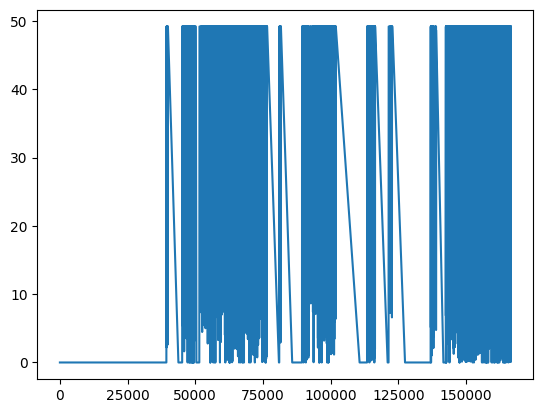

In [16]:
plt.plot(gps_lat_df)

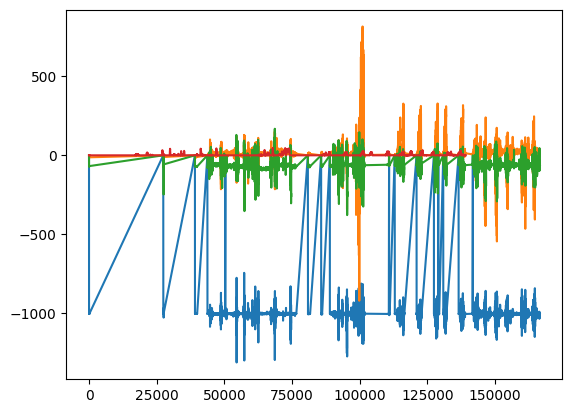

In [19]:
plt.plot(accel_x)
plt.plot(accel_y)
plt.plot(accel_z)
plt.plot(speed_df)

now that we have queried preliminary data,
- what is the Kalman filter?
- IMU data (v3 firmware) from the wiki is configured at 30Hz and GPS data is configured at 4Hz.
- this would be an extended kalman filter because of the non linearity of elements.
- The goal is to estimate the state (position and orientation) of a vehicle using both GPS and IMU data.
- IMU provides data more frequently than GPS.
- Steps:
- Initialization): The EKF state (position, velocity and orientation) using the first GPS and IMU reading. The covariance matrix (P) reflects the initial uncertainty.
- Prediction: Predict the current state using the process model and the previously estimated state. We also predict the state covariance matrix (P) at this point. this is also a timing update
- Measurement Update: We correct the predicted state using the measured data.
- Estimate update: Using Kk i.e. the Kalman gain, we can now compute an updated state estimate by combining the predicted state estimate adn the weighted difference between the actual measurement and the residual ( this is the predicted measurement based on a previous estimate).
- Update covariance: Compute the updated estimated covariance. this will ultimately become a previous estimate to base off the predicted for the next step.
- Overall process is repeated for each time step, with a recurring usage of the previous time step as a priori estimate for the current step.
-

In [ ]:
class KalmanFilter():
